Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


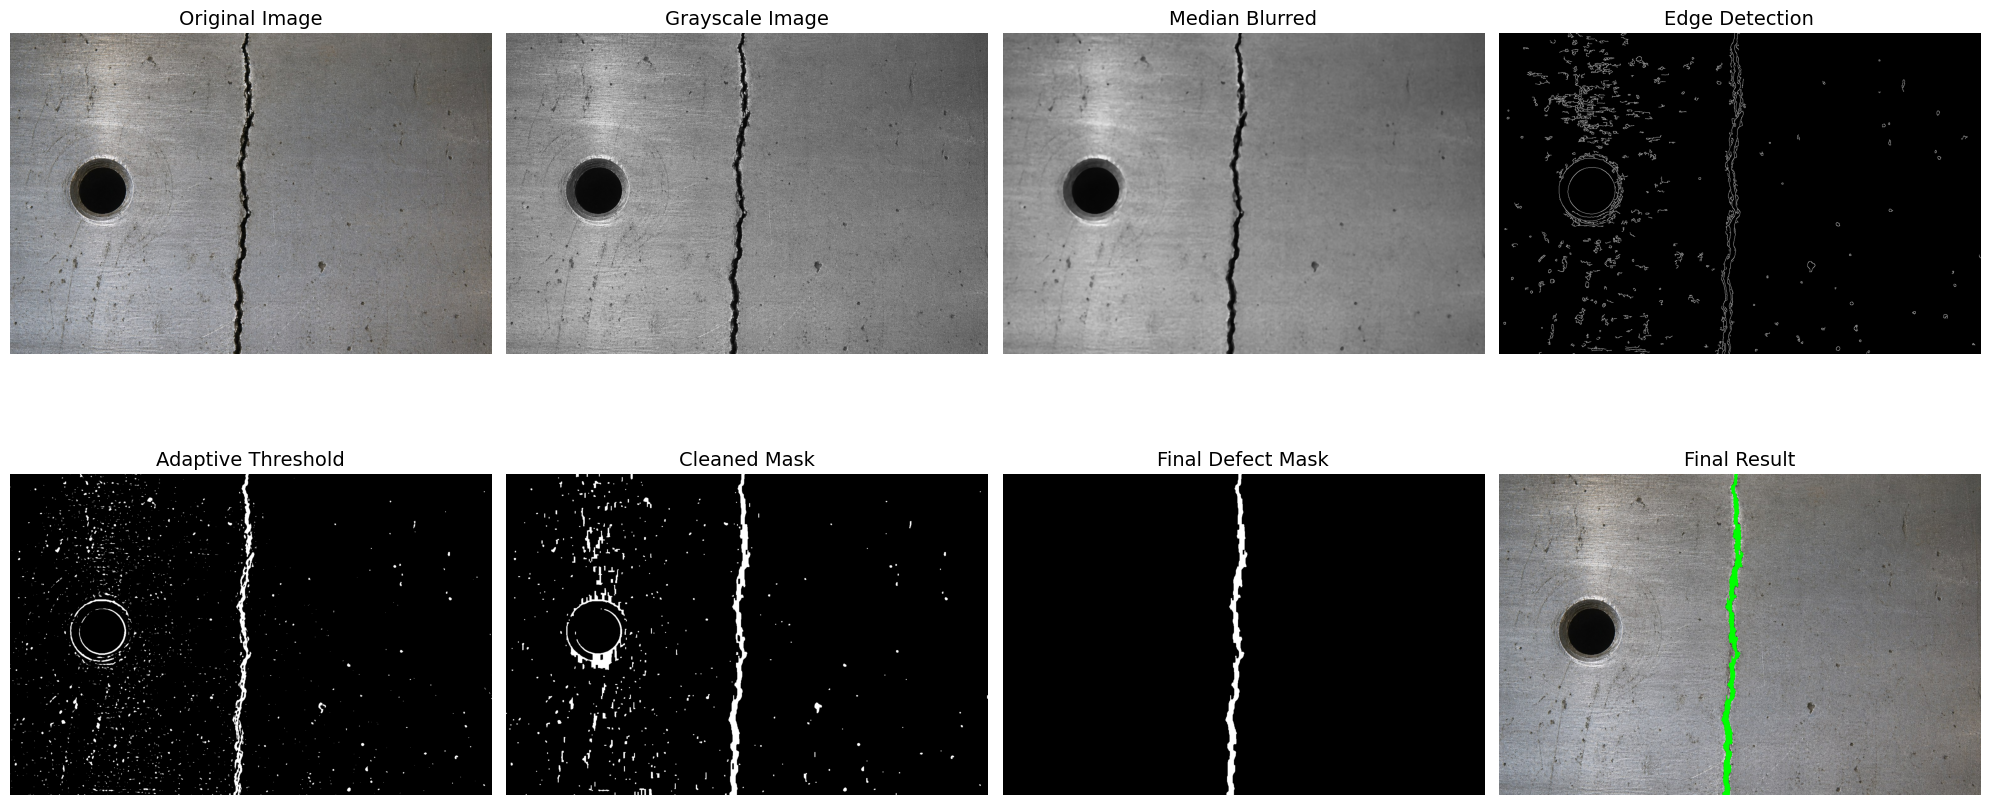

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/DIP/crack.jpg'
original_img = cv2.imread(image_path)

if original_img is not None:
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    blurred_img = cv2.medianBlur(gray_img, 7)
    edges_img = cv2.Canny(blurred_img, 30, 100)

    thresh_img = cv2.adaptiveThreshold(blurred_img, 255,
                                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 25, 10)

    kernel_close = np.ones((15, 5), np.uint8)
    mask_cleaned = cv2.morphologyEx(thresh_img, cv2.MORPH_CLOSE, kernel_close)

    kernel_open = np.ones((3, 3), np.uint8)
    mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel_open)

    contours, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    defect_mask = np.zeros_like(thresh_img)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 1000:
            x, y, w, h = cv2.boundingRect(cnt)
            if h / float(w) > 1.2:
                cv2.drawContours(defect_mask, [cnt], -1, 255, cv2.FILLED)

    final_result = original_rgb.copy()
    final_result[defect_mask == 255] = [0, 255, 0]

    titles = ['Original Image', 'Grayscale Image', 'Median Blurred', 'Edge Detection',
              'Adaptive Threshold', 'Cleaned Mask', 'Final Defect Mask', 'Final Result']
    images = [original_rgb, gray_img, blurred_img, edges_img,
              thresh_img, mask_cleaned, defect_mask, final_result]

    plt.figure(figsize=(20, 10))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])
        plt.title(titles[i], fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Xatolik: Rasm topilmadi!")